# Data Profiling — WDI African Development Indicators

Exploratory data analysis on World Bank WDI data for African countries.

**Data sources:** If `data/raw/WDICSV.csv` exists in this checkout, the notebook
rebuilds the country-year panel from the raw bulk file (full ingestion path,
including the spec §7 duplicate check). The raw CSV is ~30 MB and is not
committed, so on a fresh clone the notebook instead profiles the committed
`data/processed/model_data.parquet` — the artifact the model was actually
trained from. Both paths converge on the same coverage analysis below.

All production logic lives in `src/` (AGENTS.md rule 7); this notebook only
orchestrates and interprets.

## 1. Setup

In [1]:
# Portable root resolution: env var > git root > parent of notebooks/
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", "")) if os.environ.get("PROJECT_ROOT") else None
if PROJECT_ROOT is None:
    here = Path.cwd()
    PROJECT_ROOT = next(
        (p for p in [here, *here.parents] if (p / "pyproject.toml").exists()),
        here.parent,
    )
assert (PROJECT_ROOT / "config" / "indicators.yaml").exists(), \
    f"Could not resolve project root (got {PROJECT_ROOT})"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from src.config import load_config
from src.visualization import (
    set_project_style, plot_missingness_heatmap,
    plot_feature_distributions, plot_correlation_matrix,
)

logging.basicConfig(level=logging.WARNING)
set_project_style()

config = load_config(PROJECT_ROOT / "config" / "indicators.yaml")
print(f"Config: {len(config.features)} candidate features, "
      f"{len(config.african_countries)} country codes (54 UN member states + ESH)")
print(f"Temporal split: features {config.min_year}-{config.train_end} (train), "
      f"through {config.val_end} (val), rest (test)")

Project root: /home/user/africa-growth-ml


Config: 14 candidate features, 55 country codes (54 UN member states + ESH)
Temporal split: features 2000-2017 (train), through 2020 (val), rest (test)


## 2. Load the panel

Raw WDI is wide format (country × indicator rows, year columns). The ingestion
pipeline (`src.data` → `src.features`) reshapes it to a country-year panel with
the next-year target. `check_duplicates` implements the spec §7 policy: exact
duplicates may be collapsed, but **conflicting** `(iso3, year, indicator)`
records are logged for investigation rather than silently dropped.

In [2]:
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "WDICSV.csv"
if RAW_PATH.exists():
    from src.data import (load_wdi_csv, filter_african_countries, filter_indicators,
                          reshape_wide_to_long, pivot_to_country_year, clean_numeric,
                          check_duplicates)
    from src.features import create_target
    raw = load_wdi_csv(RAW_PATH)
    african_df = filter_african_countries(raw, african_codes=config.african_countries)
    indicator_codes = [f.code for f in config.features] + [config.target_code]
    filtered = filter_indicators(african_df, indicator_codes)
    year_cols = [str(y) for y in range(config.min_year, 2025)]
    long = reshape_wide_to_long(filtered, year_cols)
    check_duplicates(long, ["iso3", "year", "indicator_code"])  # spec s7
    panel = pivot_to_country_year(long)
    num_cols = [c for c in panel.columns if c not in ["iso3", "country_name", "year"]]
    panel = clean_numeric(panel, num_cols)
    panel = create_target(panel, config.target_code)
    source = "raw WDI CSV (full ingestion path)"
else:
    panel = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "model_data.parquet")
    source = "committed processed panel (data/raw/ not in this checkout)"

print(f"Panel source: {source}")
print(f"Shape: {panel.shape}")
print(f"Countries: {panel['iso3'].nunique()} | "
      f"Years: {int(panel['year'].min())}-{int(panel['year'].max())}")
panel.head()

Panel source: committed processed panel (data/raw/ not in this checkout)
Shape: (1300, 18)
Countries: 52 | Years: 2000-2024


,iso3,country_name,year,BX.KLT.DINV.WD.GD.ZS,EG.ELC.ACCS.ZS,FP.CPI.TOTL.ZG,FS.AST.PRVT.GD.ZS,IT.NET.USER.ZS,NE.CON.GOVT.ZS,NE.GDI.TOTL.ZS,NE.TRD.GNFS.ZS,NY.GDP.PCAP.CD,NY.GDP.PCAP.KD.ZG,SL.UEM.TOTL.ZS,SP.DYN.LE00.IN,SP.POP.GROW,SP.URB.TOTL.IN.ZS,target_next_year
0,AGO,Angola,2000,9.623866,24.2,324.996872,NaN,0.105046,NaN,NaN,NaN,563.733796,-0.302928,16.646,46.501,3.312287,50.507065,0.769185
1,AGO,Angola,2001,24.009076,20.0,152.561022,NaN,0.136014,NaN,NaN,NaN,533.586202,0.769185,16.668,47.032,3.353709,51.722479,9.857802
2,AGO,Angola,2002,10.071356,26.3,108.897436,NaN,0.270377,20.401701,29.774167,90.570821,999.065856,9.857802,16.432,47.874,3.407476,52.892623,-0.065438
3,AGO,Angola,2003,17.584059,27.4,98.224144,NaN,0.370682,23.113227,29.806955,90.680716,1133.663320,-0.065438,16.445,50.218,3.493343,54.004355,7.486047
4,AGO,Angola,2004,8.138490,28.4,43.542107,NaN,0.464815,15.079636,32.703334,90.386038,1451.471179,7.486047,16.313,51.123,3.594458,55.044528,10.067359


> **Known coverage gap (documented in `data/README.md`):** the committed
panel predates the addition of Mauritius (MUS) and Sudan (SDN) to the country
list, so it covers 52 of the 54 UN African member states. Re-running
`python -m src.data && python -m src.features` against a fresh `WDI_CSV.zip`
produces the full 54-country panel.

## 3. Indicator coverage (computed on training rows only)

Coverage thresholds applied on training rows (2000–2017) so that feature
selection never consults validation/test data (AGENTS.md rule 6).

In [3]:
feature_cols = [c for c in panel.columns
                if c not in ["iso3", "country_name", "year", "target_next_year"]]
train_mask = panel["year"] <= config.train_end

coverage = pd.DataFrame({
    "feature": feature_cols,
    "train_coverage_pct": [100 * panel.loc[train_mask, c].notna().mean() for c in feature_cols],
}).sort_values("train_coverage_pct").reset_index(drop=True)
coverage["retained"] = coverage["train_coverage_pct"] >= 60.0
coverage

,feature,train_coverage_pct,retained
0,NE.CON.GOVT.ZS,80.769231,True
1,NE.GDI.TOTL.ZS,82.478632,True
2,NE.TRD.GNFS.ZS,83.119658,True
3,FS.AST.PRVT.GD.ZS,87.820513,True
4,FP.CPI.TOTL.ZG,91.452991,True
5,NY.GDP.PCAP.KD.ZG,96.688034,True
6,BX.KLT.DINV.WD.GD.ZS,97.008547,True
7,IT.NET.USER.ZS,97.756410,True
8,SL.UEM.TOTL.ZS,98.076923,True
9,EG.ELC.ACCS.ZS,98.290598,True


### Interpretation
Features below 60% training coverage are dropped during panel construction. The committed panel was generated with this filter already applied — the one candidate historically dropped is `SE.SEC.ENRR` (secondary enrollment), just under the threshold; it no longer exists as a column here, so this run of the filter finds nothing new to drop. All 14 panel columns clear 60% training coverage (minimum shown above), including the current-year growth column that the model uses as both a feature and the persistence baseline's information source.

## 4. Missingness patterns

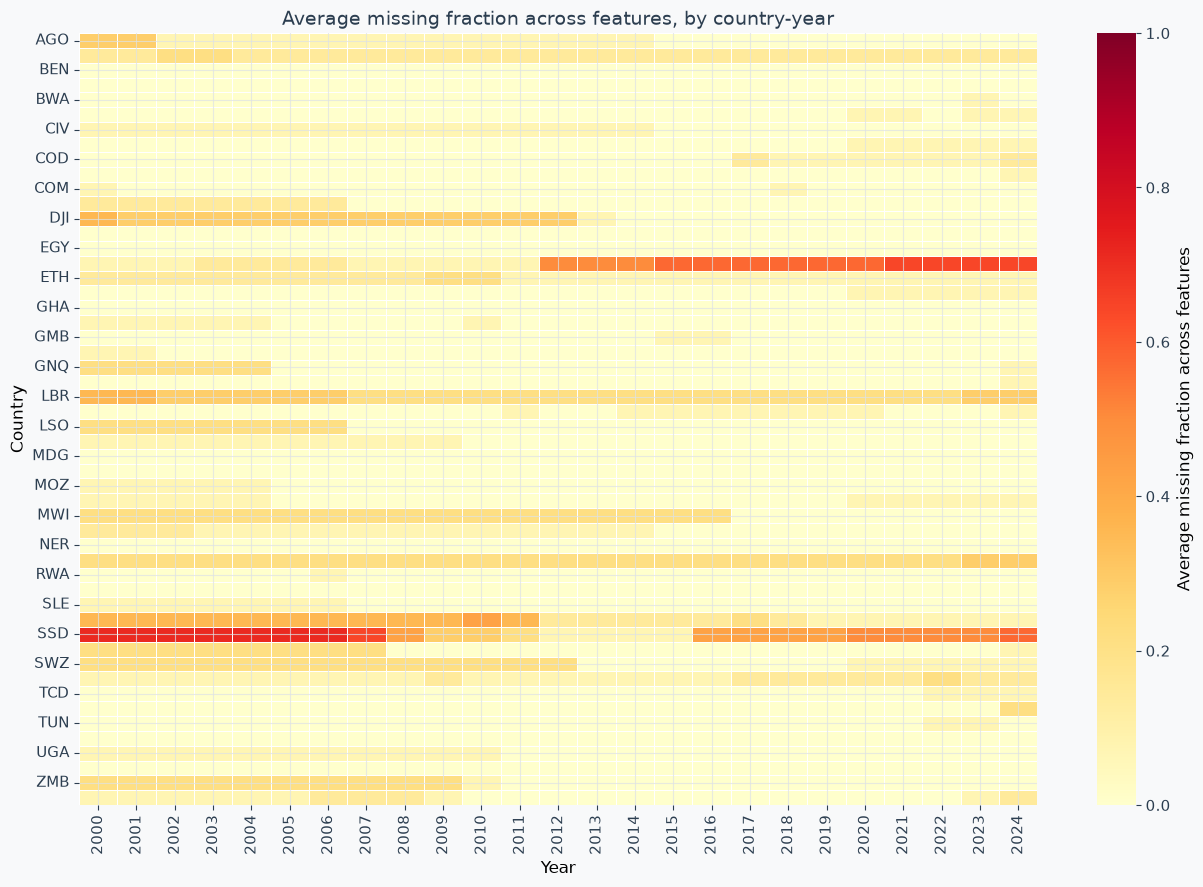

In [4]:
from src.features import select_features_by_coverage

panel_filtered = select_features_by_coverage(panel, feature_cols, min_coverage=0.6,
                                              train_mask=train_mask)
final_features = [c for c in panel_filtered.columns
                  if c not in ["iso3", "country_name", "year", "target_next_year"]]

fig, ax = plt.subplots(figsize=(13, 9))
plot_missingness_heatmap(panel_filtered.drop(columns=["target_next_year"],
                                             errors="ignore"), ax=ax,
                         title="Average missing fraction across features, by country-year")
plt.show()

### Interpretation
Darker cells = more missing feature values for that country-year. Sparse-statistics states (e.g., Somalia, South Sudan) show the heaviest missingness, which is why median imputation (training-only) is used and why coverage filtering exists in the first place.

## 5. Feature distributions

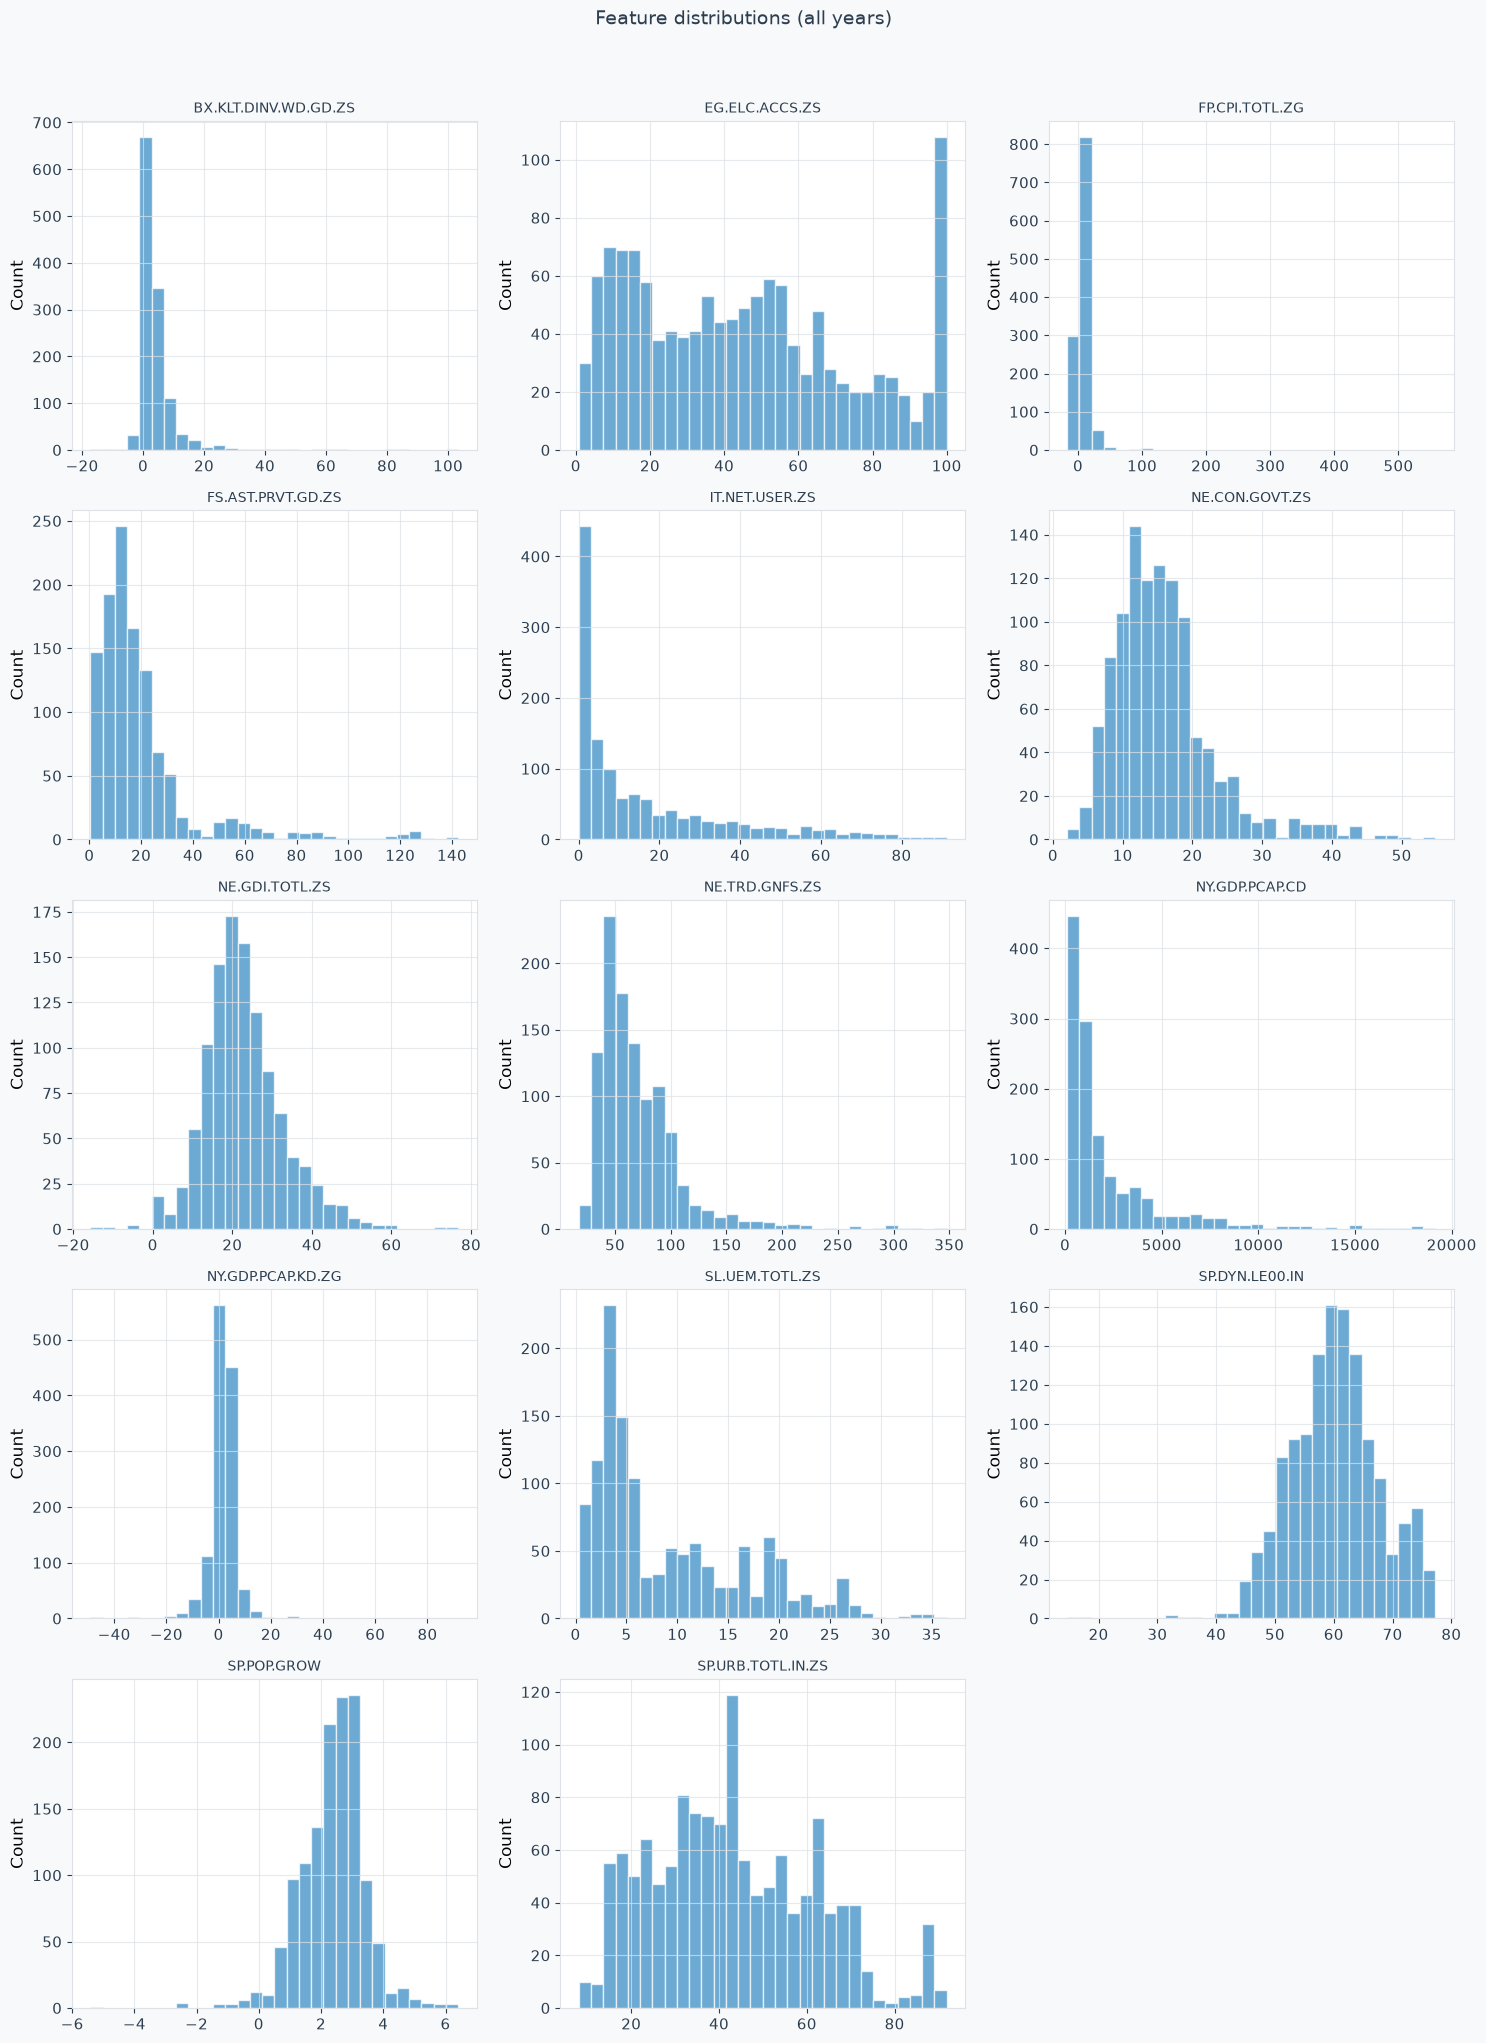

14 features profiled.


In [5]:
fig = plot_feature_distributions(panel_filtered, final_features, ncols=3,
                                 title="Feature distributions (all years)")
plt.show()
print(f"{len(final_features)} features profiled.")

### Interpretation
Most WDI indicators are skewed (GDP per capita, FDI). `NY.GDP.PCAP.CD` is log1p-transformed *inside the sklearn pipeline* (see `build_ridge_pipeline`), so no transformed columns exist in this data.

## 6. Outlier inspection

In [6]:
rows = []
for c in final_features:
    s = panel_filtered[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    rows.append({"feature": c, "min": s.min(), "p25": q1, "median": s.median(),
                 "p75": q3, "max": s.max(), "iqr_outliers": n_out})
outlier_table = pd.DataFrame(rows)
outlier_table

,feature,min,p25,median,p75,max,iqr_outliers
0,BX.KLT.DINV.WD.GD.ZS,-17.292117,1.008736,2.349860,4.970083,103.337387,97
1,EG.ELC.ACCS.ZS,0.800000,18.675000,42.650000,65.200000,100.000000,0
2,FP.CPI.TOTL.ZG,-16.859691,2.279424,5.026870,9.323879,557.201817,90
3,FS.AST.PRVT.GD.ZS,0.383077,8.767783,14.176237,22.133500,142.422046,105
4,IT.NET.USER.ZS,0.005902,1.665000,7.141000,25.000000,91.200000,74
5,NE.CON.GOVT.ZS,2.048438,11.044864,14.641001,18.796026,54.796768,56
6,NE.GDI.TOTL.ZS,-15.678444,16.587977,21.717221,28.045836,76.782325,35
7,NE.TRD.GNFS.ZS,17.400436,45.256937,60.720496,86.198848,347.720317,49
8,NY.GDP.PCAP.CD,109.593814,568.025368,1060.830213,2630.107521,19141.511874,127
9,NY.GDP.PCAP.KD.ZG,-49.127857,-0.157355,1.918036,3.687249,91.781370,106


### Interpretation
IQR-flagged extremes in inflation / FDI / growth largely correspond to real economic events (hyperinflation episodes, commodity booms and busts, conflict), not parsing errors. Per spec §7 they are **retained** — no winsorization — because the task is to predict actual growth, which is itself crisis-prone.

## 7. Correlation structure

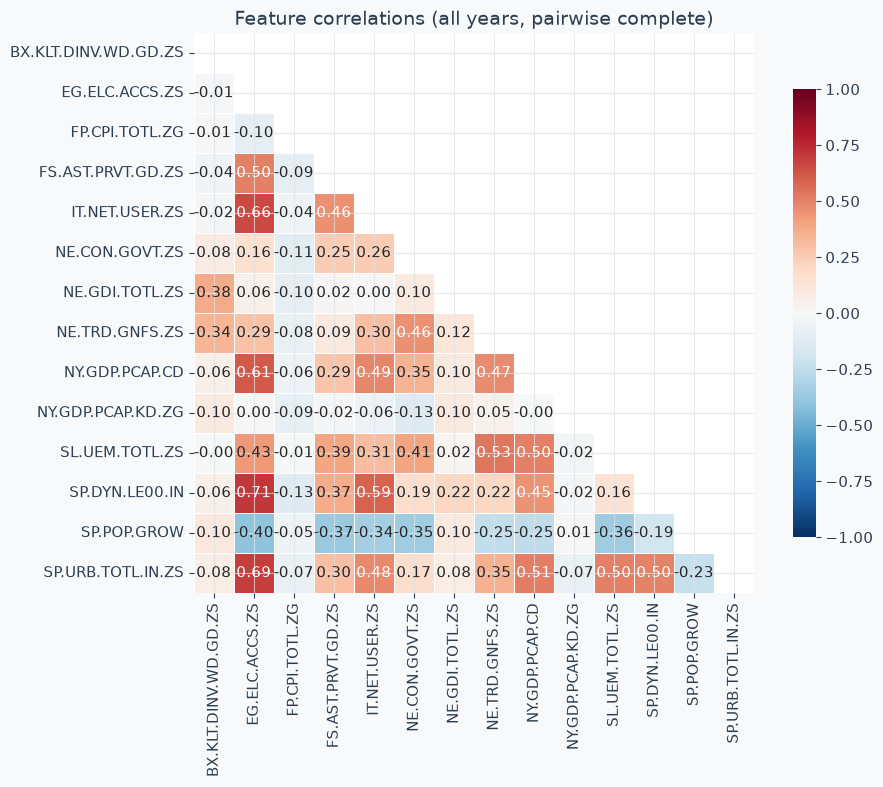

Strongest |correlations|:


EG.ELC.ACCS.ZS  SP.DYN.LE00.IN       0.710434
                SP.URB.TOTL.IN.ZS    0.692070
                IT.NET.USER.ZS       0.662381
                NY.GDP.PCAP.CD       0.611267
IT.NET.USER.ZS  SP.DYN.LE00.IN       0.588438
dtype: float64

In [7]:
corr = panel_filtered[final_features].corr()
fig = plot_correlation_matrix(panel_filtered, final_features,
                              title="Feature correlations (all years, pairwise complete)")
plt.show()
top_pairs = (corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
             .stack().abs().sort_values(ascending=False).head(5))
print("Strongest |correlations|:")
top_pairs

### Interpretation
Growth-year aggregates are slow-moving level variables, so adjacent infrastructure/technology indicators correlate strongly; none exceeds |r| > 0.8 in a way that forces de-duplication for a regularized model. Correlation ≠ causation — see the report's causal boundary (spec §2).

## 8. Final feature set decision

In [8]:
dropped = [c for c in feature_cols if c not in final_features]
print(f"Kept {len(final_features)} features; dropped {len(dropped)} (coverage < 60% on train): {dropped}")
print("\nRetained feature codes:")
for f in final_features:
    print(f"  - {f}")
print(f"\nTarget: next-year GDP per capita growth = "
      f"panel.groupby('iso3')['{config.target_code}'].shift(-1)")
print(f"Panel rows with usable target: {panel_filtered['target_next_year'].notna().sum()} "
      f"of {len(panel_filtered)}")

Kept 14 features; dropped 0 (coverage < 60% on train): []

Retained feature codes:
  - BX.KLT.DINV.WD.GD.ZS
  - EG.ELC.ACCS.ZS
  - FP.CPI.TOTL.ZG
  - FS.AST.PRVT.GD.ZS
  - IT.NET.USER.ZS
  - NE.CON.GOVT.ZS
  - NE.GDI.TOTL.ZS
  - NE.TRD.GNFS.ZS
  - NY.GDP.PCAP.CD
  - NY.GDP.PCAP.KD.ZG
  - SL.UEM.TOTL.ZS
  - SP.DYN.LE00.IN
  - SP.POP.GROW
  - SP.URB.TOTL.IN.ZS

Target: next-year GDP per capita growth = panel.groupby('iso3')['NY.GDP.PCAP.KD.ZG'].shift(-1)
Panel rows with usable target: 1205 of 1300


### Summary
The final feature set is determined by coverage analysis (>=60% on training rows). Of the 14 panel columns that reach the model, 13 are config indicators plus the current-year growth column; `SE.SEC.ENRR` was the candidate dropped for insufficient coverage during panel construction. Log-transform candidates (NY.GDP.PCAP.CD) are transformed inside the sklearn pipeline via FunctionTransformer, never as materialized columns. The committed panel covers 52 of 54 UN African member states (MUS/SDN arrive with the next WDI re-ingestion; see data/README.md).